# Algoritmo

In [ ]:
import networkx as nx

def buscar_conjuntos_backup(n, d, D, b, k):
    """
    Encuentra el conjunto de backup para cada antena utilizando Edmonds-Karp.

    Parametros:
    n (int): Cantidad de antenas.
    d (list of list): Matriz de distancias de n x n.
    D (float): Distancia máxima para que una antena sea backup.
    b (int): Cantidad máxima de conjuntos de backup a los que puede pertenecer una antena.
    k (int): Tamaño del conjunto de backup requerido para cada antena.
    """

    G = nx.DiGraph()

    # Definimos nombres para la fuente y el sumidero
    fuente = 'fuente'
    sumidero = 'sumidero'

    # Construimos el Grafo
    for i in range(1, n + 1):
        # Nodo de necesidad (antena i necesita backup)
        nodo_A = f"A_{i}"
        # Nodo proveedor (antena i ofrece backup)
        nodo_B = f"B_{i}"

        # Conexión desde la fuente a los nodos A con capacidad k
        G.add_edge(fuente, nodo_A, capacity=k)
        # Conexión desde los nodos B al sumidero con capacidad b
        G.add_edge(nodo_B, sumidero, capacity=b)

    # Conexiones entre A y B basadas en la distancia
    for i in range(1, n + 1):
        for j in range(1, n + 1):
            if i != j:  # Una antena no suele ser backup de sí misma
                # Ajustamos índices para la matriz d (que es 0-indexed en Python)
                distancia = d[i-1][j-1]
                if distancia < D:
                    G.add_edge(f"A_{i}", f"B_{j}", capacity=1)

    # 2. Ejecución de Edmonds-Karp
    # nx.maximum_flow utiliza Edmonds-Karp por defecto si se especifica la función.
    valor_flujo, flujo_dict = nx.maximum_flow(G, fuente, sumidero, flow_func=nx.algorithms.flow.edmonds_karp)

    # 3. Verificación de la solución
    flujo_esperado = n * k
    if valor_flujo < flujo_esperado:
        return None  # No existe una solución posible que cumpla las restricciones

    # 4. Reconstrucción de la solución
    resultado_backups = {}
    for i in range(1, n + 1):
        nodo_A = f"A_{i}"
        resultado_backups[i] = []

        # Revisamos a qué nodos B se les envió flujo desde A_i
        for nodo_B, flujo_enviado in flujo_dict[nodo_A].items():
            if flujo_enviado == 1:
                # Extraemos el número de la antena proveedora
                id_proveedora = int(nodo_B.split("_")[1])
                resultado_backups[i].append(id_proveedora)

    return resultado_backups

# Caso de Prueba y Seguimiento para el informe

In [ ]:
# --- Ejemplo de uso ---
if __name__ == "__main__":
    n = 3
    D = 5  # Distancia máxima de cobertura
    b = 1  # Máximo de veces que una antena puede ser backup
    k = 1

    # Matriz de distancias de ejemplo (4x4)
    matriz_distancias = [
        [0,  3,  4],
        [3,  0,  4],
        [4,  4,  0],
    ]

    solucion = buscar_conjuntos_backup(n, matriz_distancias, D, b, k)
    print(solucion)

    if solucion:
        print("¡Solución encontrada exitosamente!")
        for antena, backups in solucion.items():
            print(f"Antena {antena} -> Conjunto de backup: {backups}")
    else:
        print("No existe una solución posible con las restricciones dadas.")

{1: [2], 2: [3], 3: [1]}
¡Solución encontrada exitosamente!
Antena 1 -> Conjunto de backup: [2]
Antena 2 -> Conjunto de backup: [3]
Antena 3 -> Conjunto de backup: [1]


# Mediciones

## Generación de datos y pruebas

In [ ]:
import time
import random
import numpy as np

def generar_instancia_aleatoria(n, max_dist=10, seed=42):
    """
    Genera una matriz de distancias simétrica de n x n con diagonal 0
    utilizando una semilla fija para asegurar reproducibilidad.
    """
    random.seed(seed)
    np.random.seed(seed)

    matriz_base = np.random.uniform(1, max_dist, size=(n, n))
    matriz_dist = (matriz_base + matriz_base.T) / 2
    np.fill_diagonal(matriz_dist, 0)

    return matriz_dist.tolist()

# --- Configuración del Experimento ---
valores_n = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
D = 6.0   # Distancia máxima admisible
k = 2     # Backups requeridos por antena
b = 3     # Límite de soporte por antena

tiempos_medidos = []
resultados_experimentos = {}

print("Iniciando mediciones de tiempo de ejecución...")
print("-" * 50)

for n in valores_n:
    # Generar el set de datos para este tamaño
    matriz_d = generar_instancia_aleatoria(n, max_dist=10, seed=42)

    # Tomar tiempos antes y después de la ejecución
    inicio = time.time()
    solucion = buscar_conjuntos_backup(n, matriz_d, D, b, k)
    fin = time.time()

    tiempo_total = fin - inicio
    tiempos_medidos.append(tiempo_total)

    estado = "Exitoso" if solucion is not None else "No Factible"
    resultados_experimentos[n] = estado
    print(f"n = {n:3d} | Tiempo: {tiempo_total:.5f} seg | Estado: {estado}")

print("-" * 50)
print("¡Mediciones completadas!")

Iniciando mediciones de tiempo de ejecución...
--------------------------------------------------
n =  10 | Tiempo: 0.00208 seg | Estado: Exitoso
n =  20 | Tiempo: 0.00308 seg | Estado: Exitoso
n =  30 | Tiempo: 0.00580 seg | Estado: Exitoso
n =  40 | Tiempo: 0.01126 seg | Estado: Exitoso
n =  50 | Tiempo: 0.01438 seg | Estado: Exitoso
n =  60 | Tiempo: 0.02049 seg | Estado: Exitoso
n =  70 | Tiempo: 0.02854 seg | Estado: Exitoso
n =  80 | Tiempo: 0.03522 seg | Estado: Exitoso
n =  90 | Tiempo: 0.04726 seg | Estado: Exitoso
n = 100 | Tiempo: 0.05957 seg | Estado: Exitoso
--------------------------------------------------
¡Mediciones completadas!


## Gráficos

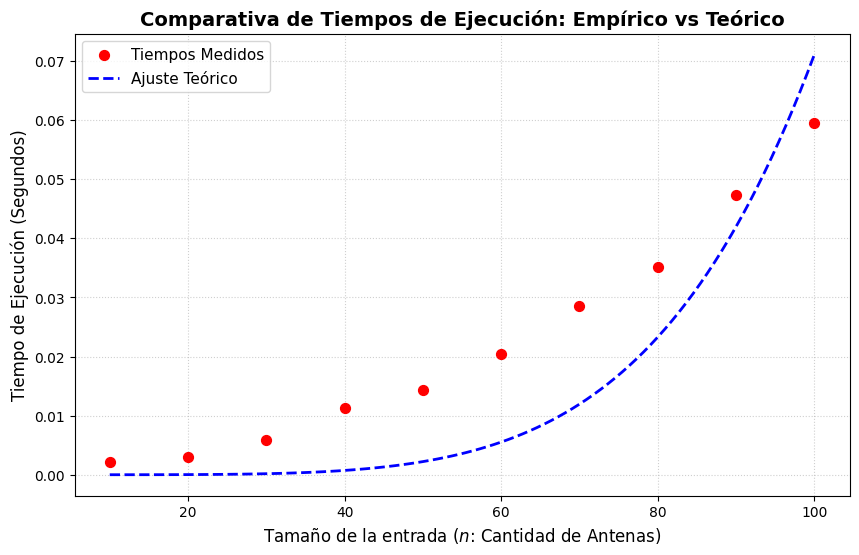

In [ ]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Función matemática de la complejidad teórica: f(n) = c * n^5
def funcion_teorica_n5(n, c):
    return c * (n ** 5)

# Calculamos el coeficiente óptimo 'c' que mejor ajusta tus tiempos medidos
popt, _ = curve_fit(funcion_teorica_n5, valores_n, tiempos_medidos)
c_optimo = popt[0]

# Generamos puntos intermedios densos para que la curva teórica se vea suave
n_curva = np.linspace(min(valores_n), max(valores_n), 100)
tiempos_teoricos = funcion_teorica_n5(n_curva, c_optimo)

# --- Configuración Estética del Gráfico ---
plt.figure(figsize=(10, 6))

# Dibujar puntos empíricos
plt.scatter(valores_n, tiempos_medidos, color='red', s=50, label='Tiempos Medidos', zorder=5)

# Dibujar línea teórica de ajuste
plt.plot(n_curva, tiempos_teoricos, color='blue', linestyle='--', linewidth=2,
         label=f'Ajuste Teórico')

# Detalles de etiquetas y diseño
plt.title('Comparativa de Tiempos de Ejecución: Empírico vs Teórico', fontsize=14, fontweight='bold')
plt.xlabel('Tamaño de la entrada ($n$: Cantidad de Antenas)', fontsize=12)
plt.ylabel('Tiempo de Ejecución (Segundos)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11, loc='upper left')

# Mostrar el gráfico en el Colab
plt.show()